# Imports

In [20]:
import numpy as np 
import h5py
import warnings

from egb_jax_eccentric import (
    EccentricBinaryParams,
    aet_from_xyz,
    eccentric_complex_strain,
    eccentric_links_jax,
    eccentric_xyz_jax,
    lisa_orbit,
    precompute_jax_link_geometry,
    prebuild_michelson,
    default_lisaorbits, 
    state_from_lisaorbits
)
from egb_jax_eccentric.constants import PARSEC_M#, KILOPARSEC_M
from astropy.coordinates import SkyCoord, BarycentricTrueEcliptic
import astropy.units as u
import json
from scipy.signal import welch
import matplotlib.pyplot as plt
import dynesty
import jax
import jax.numpy as jnp
import blackjax


E0918 13:10:07.015196  653827 cuda_executor.cc:1182] [0] Failed to allocate device memory of 33.32GiB (35775315968 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0918 13:10:07.015893  653827 cuda_executor.cc:1182] [0] Failed to allocate device memory of 29.99GiB (32197783552 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0918 13:10:07.016411  653827 cuda_executor.cc:1182] [0] Failed to allocate device memory of 26.99GiB (28978003968 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0918 13:10:07.016718  653827 cuda_executor.cc:1182] [0] Failed to allocate device memory of 24.29GiB (26080202752 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0918 13:10:07.017012  653827 cuda_executor.cc:1182] [0] Failed to allocate device memory of 21.86GiB (23472181248 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0918 13:10:07.017272  653827 cuda_executor.cc:1182] [0] Failed to allocate

In [5]:
import os
work_dir='/home/svu/e1498138/localgit/eGB-multi'
scratch_dir='/scratch/e1498138/eGB-multi'
os.chdir(work_dir)

inj_path = scratch_dir + '/sangria_hmcnc_true.h5'

# Read injected file

In [6]:
XYZ = ("X", "Y", "Z")
AET = ("A", "E", "T")

In [7]:
with h5py.File(inj_path, "r") as f:
    t = f["t"][:]
    noise_xyz = {"t": t, **{ch: f["noise"][ch][:] for ch in XYZ}}
    signal_xyz = {ch: f["eccentric_signal"][ch][:] for ch in XYZ}
    injected_xyz = {"t": t, **{ch: f["injected"][ch][:] for ch in XYZ}}

    dt = f.attrs["segment_dt_s"]
    sangria_metadata = json.loads(f.attrs["sangria_metadata_json"])
    source_params = json.loads(f.attrs["egb_source_params_json"])

print("samples:", t.size, "dt:", dt)
print("source_params:", json.dumps(source_params, indent=2))


samples: 518400 dt: 5.0
source_params: {
  "f0_hz": 0.00622027623506547,
  "eccentricity": 0,
  "m1_solar": 0.55,
  "m2_solar": 0.27,
  "distance_m": 2.3142581861185254e+20,
  "beta": -0.08210049881437637,
  "lambda_": 2.102052384246663,
  "psi": 0.0,
  "inclination": 0.6632251157578453,
  "phi0": 0.0,
  "fdot": 0.0
}


In [8]:
state = state_from_lisaorbits(default_lisaorbits("equal"), t)
geometry = precompute_jax_link_geometry(state)

egb_pytdi_gen = 1
measurement_order = 3
delay_order = 3

# pyTDI's build step depends only on the geometry, not on the source, so hoist it
# out of the likelihood loop the same way geometry is (~2x faster per call)
prebuilt = prebuild_michelson(state, generation=egb_pytdi_gen, delay_order=delay_order)

/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


# Rotate to AET & PSD Estimate

In [9]:
noise_aet = aet_from_xyz(noise_xyz)
signal_aet = aet_from_xyz(signal_xyz)
injected_aet = aet_from_xyz(injected_xyz)

print("noise AET max abs:", {ch: float(np.max(np.abs(noise_aet[ch]))) for ch in AET})
print("signal AET max abs:", {ch: float(np.max(np.abs(signal_aet[ch]))) for ch in AET})


noise AET max abs: {'A': 4.3858327704197363e-20, 'E': 4.459085751762551e-20, 'T': 5.263813956477628e-20}
signal AET max abs: {'A': 2.626181161966582e-23, 'E': 1.2889563994147257e-23, 'T': 6.743698074007531e-26}


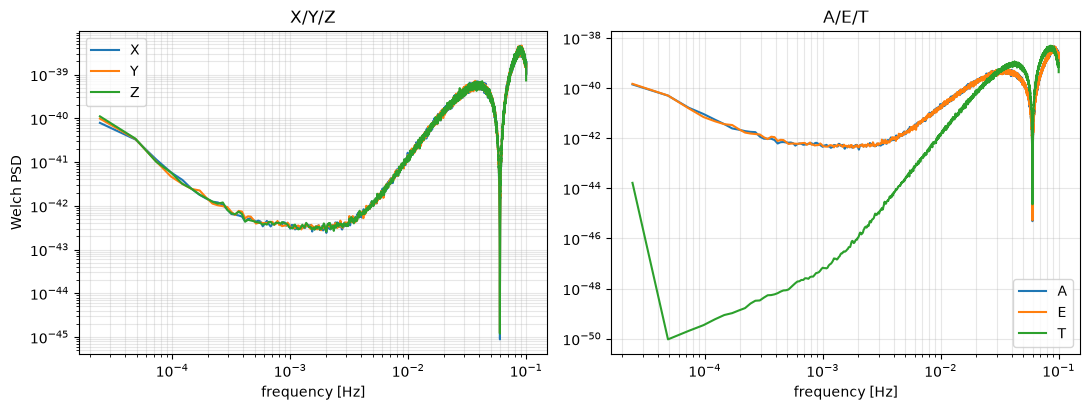

In [10]:

fs = 1.0 / dt
nperseg = 8192 #like in the paper but do note its for dt=10s
# get psd on same grid
# nperseg = noise_xyz["X"].size 

psd_xyz, psd_aet = {}, {}
for ch in XYZ:
    freq, psd_xyz[ch] = welch(noise_xyz[ch], fs=fs, nperseg=nperseg, detrend="constant")
for ch in AET:
    _, psd_aet[ch] = welch(noise_aet[ch], fs=fs, nperseg=nperseg, detrend="constant")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ch in XYZ:
    axes[0].loglog(freq[1:], psd_xyz[ch][1:], label=ch)
axes[0].set_title("X/Y/Z")

for ch in AET:
    axes[1].loglog(freq[1:], psd_aet[ch][1:], label=ch)
axes[1].set_title("A/E/T")

for ax in axes:
    ax.set_xlabel("frequency [Hz]")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
axes[0].set_ylabel("Welch PSD")

fig.tight_layout()
plt.show()


# FFT of injected data

In [11]:
def fdom(x, dt):
    n = x.size
    xf = np.fft.rfft(x) * dt
    freq = np.fft.rfftfreq(n, d=dt)
    return freq, xf

ll_chan = ("A", "E") #exclude T cuz we hate it C:


In [12]:
data_freq, data_fd = {}, {}
for ch in ll_chan:
    data_freq_i, data_fd_i = fdom(injected_aet[ch], dt)
    data_freq[ch] = data_freq_i
    data_fd[ch] = data_fd_i


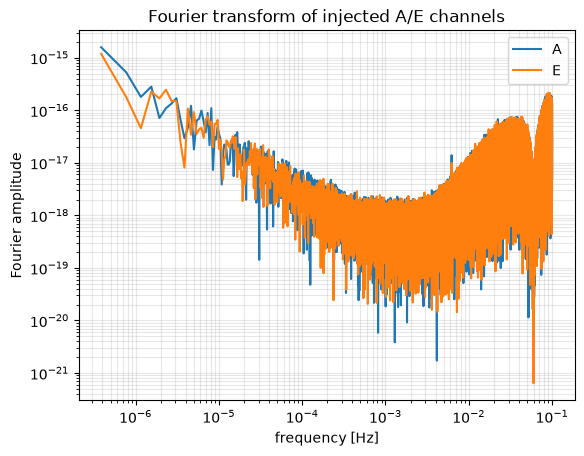

In [13]:
for ch in ll_chan:
    plt.loglog(data_freq[ch][1:], np.abs(data_fd[ch][1:]), label=ch)
plt.xlabel("frequency [Hz]")
plt.ylabel("Fourier amplitude")
plt.grid(alpha=0.3, which="both")
plt.title("Fourier transform of injected A/E channels")
plt.legend()
plt.show()


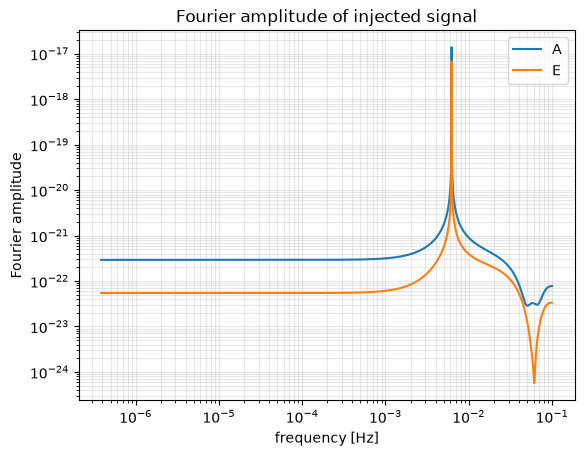

In [14]:
for ch in ll_chan:
    freq_s, xf = fdom(signal_aet[ch], dt)
    plt.loglog(freq_s[1:], np.abs(xf[1:]), label=ch)
plt.xlabel("frequency [Hz]")
plt.ylabel("Fourier amplitude")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.title("Fourier amplitude of injected signal")
plt.show()

# Interpolate PSD on the same grid

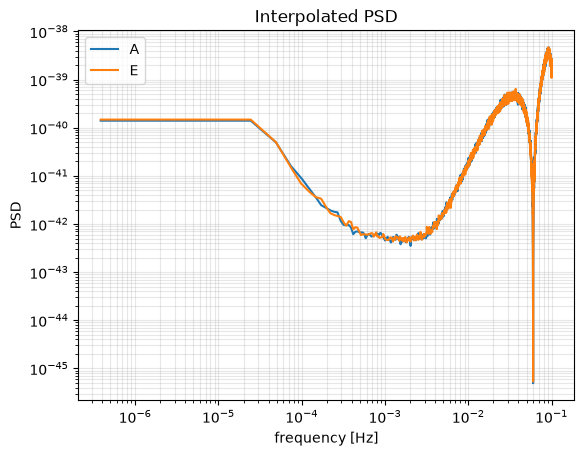

In [15]:
def psd_on_grid(freq_grid, welch_freq, welch_psd):
    safe = welch_freq > 0
    log_psd = np.interp(np.log(freq_grid[freq_grid > 0]),
                         np.log(welch_freq[safe]), np.log(welch_psd[safe]))
    out = np.full_like(freq_grid, np.inf)
    out[freq_grid > 0] = np.exp(log_psd)
    return out

psd_grid = {}
for ch in ll_chan:
    psd_grid[ch] = psd_on_grid(data_freq[ch], freq, psd_aet[ch])
    plt.loglog(data_freq[ch][1:], psd_grid[ch][1:], label=ch)

plt.xlabel("frequency [Hz]")
plt.ylabel("PSD")
plt.grid(alpha=0.3, which="both")
plt.title("Interpolated PSD")
plt.legend()
plt.show()

# Waveform template func

In [16]:
def htemp(params):
    # params to vary
    ecc_i, m1_sol_i, m2_sol_i = params
    source_temp = EccentricBinaryParams(
        mean_motion=np.pi * source_params["f0_hz"],
        eccentricity=ecc_i,
        m1_solar=m1_sol_i,
        m2_solar=m2_sol_i,
        distance_m=source_params["distance_m"],
        beta=source_params["beta"],
        lambda_=source_params["lambda_"],
        psi=source_params["psi"],
        inclination=source_params["inclination"],
        phi0=source_params["phi0"],
        fdot=source_params["fdot"],
    )

    raw_temp_xyz = eccentric_xyz_jax(
        state,
        source_temp,
        geometry=geometry,
        prebuilt=prebuilt,
        batch_size=1, #NOTE: think abt different sampler that is able to handle batched pool evaluations
        physics_mode="1pn_periastron", #NOTE: 1pn
        generation=egb_pytdi_gen,
        measurement_order=measurement_order,
        delay_order=delay_order,
    )
    
    xyz = {ch: np.real(np.asarray(raw_temp_xyz[ch], dtype=np.complex128)) for ch in XYZ}
    return aet_from_xyz(xyz)

# Log likelihood

In [17]:
# take freq min of the welch psd 
# its abt 10^-5 meanwhile injected data goes to 10^-7..

freq_min = freq[freq > 0].min()
freq_mask = data_freq["A"] >= freq_min

df = data_freq["A"][1] - data_freq["A"][0]

expand $-\frac12\langle d-h|d-h\rangle = -\frac12 \langle d|d\rangle + \langle d|h \rangle - \frac12 \langle h|h \rangle$

In [ ]:
# def log_likelihood(params):
#     template_aet = htemp(params)
#     logl = 0.0
#     for ch in ("A", "E"):
#         _, h_fd = fdom(template_aet[ch], dt)
#         d = data_fd[ch][freq_mask]
#         h = h_fd[freq_mask]
#         sn = psd_grid[ch][freq_mask]
#         dh = 4.0 * np.sum(np.real(d * np.conj(h)) / sn) * df
#         hh = 4.0 * np.sum(np.real(h * np.conj(h)) / sn) * df
#         logl += dh - 0.5 * hh
#     return float(logl)

vectorized 

In [18]:
# --- one-off setup, next to freq_mask/df ---
i0 = int(np.searchsorted(data_freq["A"], freq_min))  

# fold all constants (4, df, dt, 1/Sn) into precomputed weights
w_hh = {ch: 4.0 * df * dt**2 / psd_grid[ch][i0:] for ch in ll_chan}
d_w  = {ch: 4.0 * df * dt * data_fd[ch][i0:] / psd_grid[ch][i0:] for ch in ll_chan}


def log_likelihood(params):
    template_aet = htemp(params)
    logl = 0.0
    for ch in ll_chan:
        h = np.fft.rfft(template_aet[ch])[i0:]        # raw rfft; dt folded into weights above
        dh = np.vdot(h, d_w[ch]).real                 # sum(conj(h) * 4 df dt d / Sn)
        hh = np.sum((h.real**2 + h.imag**2) * w_hh[ch])
        logl += dh - 0.5 * hh
    return float(logl)

# Priors

In [19]:
def prior_transform(u):
    ecc_u, m1_u, m2_u = u
    eccentricity = ecc_u * 0.9          # uniform prior: e in [0, 0.9)
    m1_solar = 0.1 + m1_u * (1.5 - 0.1)  # uniform prior: m1 in [0.1, 1.5] Msun
    m2_solar = 0.1 + m2_u * (1.5 - 0.1)  # same range for m2
    return eccentricity, m1_solar, m2_solar


In [21]:
bounds =  np.array([[0.0, 0.9], [0.1, 1.5], [0.1, 1.5]])
def logdensity_fn(theta):
    params = np.asarray(theta, dtype=np.float64)
    # uniform priors
    if np.any(params < bounds[:, 0]) or np.any(params > bounds[:, 1]):
        return jnp.asarray(-np.inf)
    return jnp.asarray(log_likelihood(params))

# Sample try

In [22]:
theta_true = np.array(
    [source_params["eccentricity"], source_params["m1_solar"], source_params["m2_solar"]]
)


In [23]:
import time
t0 = time.time()
ll_true = logdensity_fn(theta_true)
print("log likelihood at true params:", ll_true)
print("one call takes:", time.time() - t0, "seconds")


/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/pytdi/dsp.py:72: ComplexWarning: Casting complex values to real discards the imaginary part
  return data.astype(float)


log likelihood at true params: 128.85711119576692
one call takes: 4.438152313232422 seconds


In [24]:
t0 = time.time()
ll_arb=logdensity_fn([0.5, 0.8, 0.9])
print("log likelihood at arbitrary params:", ll_arb)
print("second call takes:", time.time() - t0, "seconds")


log likelihood at arbitrary params: -1512.0867356174385
second call takes: 1.502312183380127 seconds


In [25]:
t0 = time.time()
print("log likelihood at arbitrary params:", logdensity_fn([0.2, 0.3, 0.5]))
print(" call takes:", time.time() - t0, "seconds")


log likelihood at arbitrary params: 94.06840058124396
 call takes: 1.5681824684143066 seconds


# BJBJBJBJ

In [30]:
N_STEPS = 100
CHECKPOINT_EVERY = 10
# RWM proposal width per parameter (ecc, m1, m2). Tune so acceptance lands ~0.2-0.3.
SIGMA = np.array([0.01, 0.03, 0.03])
chain_path = scratch_dir + "/hmcnc_blackjax_chain.npz"

rng = jax.random.key(0)

kernel = blackjax.additive_step_random_walk.normal_random_walk(
    logdensity_fn, sigma=jnp.asarray(SIGMA)
)

position = jnp.asarray(theta_true)
sampler_state = kernel.init(position)

chain = np.empty((N_STEPS, 3))
logdens = np.empty(N_STEPS)
n_accept = 0
t_start = time.time()

for i in range(N_STEPS):
    rng, subkey = jax.random.split(rng)
    sampler_state, info = kernel.step(subkey, sampler_state)

    chain[i] = np.asarray(sampler_state.position)
    logdens[i] = float(sampler_state.logdensity)
    n_accept += bool(info.is_accepted)

    if (i + 1) % CHECKPOINT_EVERY == 0:
        elapsed = time.time() - t_start
        np.savez(
            chain_path,
            chain=chain[: i + 1],
            logdensity=logdens[: i + 1],
            sigma=SIGMA,
            bounds=bounds,
            truth=theta_true,
            n_steps_done=i + 1,
            acceptance=n_accept / (i + 1),
        )
        print(
            f"step {i + 1}/{N_STEPS} | acc {n_accept / (i + 1):.3f} | "
            f"logp {logdens[i]:.2f} | {elapsed / (i + 1):.2f} s/step | "
            f"e={chain[i, 0]:.4f} m1={chain[i, 1]:.4f} m2={chain[i, 2]:.4f}",
            flush=True,
        )


step 10/100 | acc 0.100 | logp 128.89 | 0.53 s/step | e=0.0029 m1=0.5643 m2=0.2682
step 20/100 | acc 0.350 | logp 128.00 | 0.81 s/step | e=0.0033 m1=0.5437 m2=0.3176
step 30/100 | acc 0.367 | logp 128.45 | 0.85 s/step | e=0.0099 m1=0.5673 m2=0.2920
step 40/100 | acc 0.375 | logp 128.97 | 0.86 s/step | e=0.0024 m1=0.5535 m2=0.2753
step 50/100 | acc 0.300 | logp 128.97 | 0.80 s/step | e=0.0024 m1=0.5535 m2=0.2753
step 60/100 | acc 0.317 | logp 126.32 | 0.85 s/step | e=0.0355 m1=0.6523 m2=0.2663
step 70/100 | acc 0.357 | logp 125.71 | 0.91 s/step | e=0.0348 m1=0.8065 m2=0.2333
step 80/100 | acc 0.338 | logp 128.42 | 0.94 s/step | e=0.0215 m1=0.8616 m2=0.1999
step 90/100 | acc 0.344 | logp 128.97 | 0.93 s/step | e=0.0085 m1=0.8775 m2=0.1930
step 100/100 | acc 0.360 | logp 127.89 | 0.97 s/step | e=0.0156 m1=0.9132 m2=0.2051
